In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from pathlib import Path
import re

data_dir = Path("data_chest/chest_Xray")

# Exclusion des radiographies des patients avec une pneumonie mixte (bacteria + virus)

In [ ]:
from collections import defaultdict

patients_ambigus = set()
patient_pathologies = defaultdict(set)

for img_path in data_dir.rglob("*.jp*g"):
    filename = img_path.name.lower()
    
    # Extraction rapide de l'ID
    if "person" in filename:
        pid = re.match(r"(person\d+)", filename)
        pid = pid.group(1) if pid else None
    elif filename.startswith("im-"):
        pid = re.match(r"(im-\d+)", filename)
        pid = pid.group(1).upper() if pid else None
    else:
        pid = filename.split('_')[0].split('-')[0]
        
    if pid:
        if "bacteria" in filename:
            patient_pathologies[pid].add("BACTERIA")
        elif "virus" in filename:
            patient_pathologies[pid].add("VIRUS")

# On remplit le set des exclus
for pid, pathologies in patient_pathologies.items():
    if "BACTERIA" in pathologies and "VIRUS" in pathologies:
        patients_ambigus.add(pid)

print(f"ℹ️ {len(patients_ambigus)} patients ambigus (Bactérie + Virus) détectés de manière globale. Ils seront ignorés.")

ℹ️ 979 patients ambigus (Bactérie + Virus) détectés de manière globale. Ils seront ignorés.


In [ ]:

def extract_patient_ids(split_name):
    patient_ids = set()
    split_path = data_dir / split_name
    
    # On parcourt toutes les images (.jpeg ou .jpg) dans les sous-dossiers
    for img_path in split_path.rglob("*.jp*g"):
        filename = img_path.name
        
        # Cas 1 : Format "personXXX_..." (Pneumonie)
        if "person" in filename:
            match = re.match(r"(person\d+)", filename)
            if match:
                patient_ids.add(match.group(1))
        
        # Cas 2 : Format "IM-XXXX-..." (cas Normaux : mais peut-être aussi ID d'images : on les identifie sans les supprimer)
        elif filename.startswith("IM-"):
            match = re.match(r"(IM-\d+)", filename)
            if match:
                patient_ids.add(match.group(1))
        
        # Cas 3 : Sécurité si le format varie (on prend le premier bloc avant le premier tiret/underscore)
        else:
            fallback_id = filename.split('_')[0].split('-')[0]
            patient_ids.add(fallback_id)
            
    return patient_ids

# Extraction des IDs pour chaque groupe
train_patients = extract_patient_ids("train")
test_patients = extract_patient_ids("test")
val_patients = extract_patient_ids("val")

print(f"Nombre de patients uniques - Train: {len(train_patients)}, Test: {len(test_patients)}, Val: {len(val_patients)}")

Nombre de patients uniques - Train: 2154, Test: 268, Val: 8


In [ ]:
# --- VERIFICATION DES INTERSECTIONS  : fonction intersection()
leak_train_test = train_patients.intersection(test_patients)
leak_train_val = train_patients.intersection(val_patients)
leak_val_test = val_patients.intersection(test_patients)

print("\n--- Résultats de la vérification ---")
if leak_train_test:
    print(f"❌ FUITE DÉTECTÉE entre Train et Test ! ({len(leak_train_test)} patients en commun)")
    print(f"IDs corrompus : {list(leak_train_test)}")
else:
    print("✅ Pas de fuite entre Train et Test.")

if leak_train_val:
    print(f"❌ FUITE DÉTECTÉE entre Train et Val ! ({len(leak_train_val)} patients en commun)")
    print(f"IDs corrompus : {list(leak_train_val)}")
else:
    print("✅ Pas de fuite entre Train et Val.")

if leak_val_test:
    print(f"❌ FUITE DÉTECTÉE entre Val et Test ! ({len(leak_val_test)} patients en commun)")
    print(f"IDs corrompus : {list(leak_val_test)}")
else:
    print("✅ Pas de fuite entre Val et Test.")


--- Résultats de la vérification ---
❌ FUITE DÉTECTÉE entre Train et Test ! (171 patients en commun)
IDs corrompus : ['person126', 'person75', 'person55', 'person48', 'person1669', 'person61', 'person153', 'person1628', 'person1649', 'person1613', 'person1668', 'person94', 'person137', 'person10', 'person71', 'person1614', 'person39', 'person44', 'person139', 'person1657', 'NORMAL2', 'person132', 'person97', 'person1671', 'person1635', 'person145', 'person20', 'person102', 'person87', 'person103', 'person47', 'person1615', 'person1680', 'person90', 'person1670', 'person1618', 'person59', 'person36', 'person16', 'person1678', 'person128', 'person76', 'person104', 'person154', 'person1625', 'person22', 'person1644', 'person1620', 'person1629', 'person109', 'person50', 'person77', 'person133', 'person1640', 'person41', 'person112', 'person89', 'person114', 'person70', 'person21', 'person17', 'person74', 'person28', 'person66', 'person124', 'person88', 'person11', 'person149', 'person1679

In [ ]:
# on isole les ID des patients à "pneumonies mixtes" (??)
patients_a_exclure = set(leak_train_test)
patients_a_exclure.discard("NORMAL2")

print(f"Nombre d'IDs de patients à filtrer : {len(patients_a_exclure)}")

# 2. Nettoyage des sets existants en soustrayant les exclus
# L'opérateur '-' retire du set de gauche tous les éléments présents dans le set de droite
train_patients_clean = train_patients - patients_a_exclure
test_patients_clean = test_patients - patients_a_exclure
val_patients_clean = val_patients - patients_a_exclure

print(f"\n--- Nombre de patients uniques APRÈS filtrage ---")
print(f"Train: {len(train_patients_clean)}, Test: {len(test_patients_clean)}, Val: {len(val_patients_clean)}")

Nombre d'IDs de patients à filtrer : 170

--- Nombre de patients uniques APRÈS filtrage ---
Train: 1984, Test: 98, Val: 8


## Dataframe de base "nettoyé"

In [ ]:
data_records = []

# Dictionnaire pour associer chaque split à son set de patients propres
clean_splits = {
    "train": train_patients_clean,
    "test": test_patients_clean,
    "val": val_patients_clean
}

for split_name, clean_patients in clean_splits.items():
    split_path = data_dir / split_name
    
    for img_path in split_path.rglob("*.jp*g"):
        filename = img_path.name
        
        # On extrait l'ID
        if "person" in filename:
            match = re.match(r"(person\d+)", filename)
            pid = match.group(1) if match else None
        elif filename.startswith("IM-"):
            match = re.match(r"(IM-\d+)", filename)
            pid = match.group(1) if match else None
        else:
            pid = filename.split('_')[0].split('-')[0]
            
        # On ne garde l'image que si le patient fait partie du set nettoyé
        if pid in clean_patients:
            # On détermine le label (NORMAL, BACTERIA, VIRUS) basé sur le nom du fichier
            if "bacteria" in filename.lower():
                label = "BACTERIA"
            elif "virus" in filename.lower():
                label = "VIRUS"
            else:
                label = "NORMAL" # Les fichiers IM-XXXX ou sans mention
                
            # On enregistre les infos de l'image dans la liste data_records
            data_records.append({
                "path": str(img_path),
                "patient_id": pid,
                "label": label,
                "split": split_name
            })

df = pd.DataFrame(data_records)
print(f"✅ DataFrame créé avec succès ! Nombre total d'images conservées : {len(df)}")
print(df["split"].value_counts())

✅ DataFrame créé avec succès ! Nombre total d'images conservées : 5079
split
train    4759
test      304
val        16
Name: count, dtype: int64


In [ ]:
df.head()

,path,patient_id,label,split
0,data_chest\chest_Xray\train\NORMAL\IM-0115-000...,IM-0115,NORMAL,train
1,data_chest\chest_Xray\train\NORMAL\IM-0117-000...,IM-0117,NORMAL,train
2,data_chest\chest_Xray\train\NORMAL\IM-0119-000...,IM-0119,NORMAL,train
3,data_chest\chest_Xray\train\NORMAL\IM-0122-000...,IM-0122,NORMAL,train
4,data_chest\chest_Xray\train\NORMAL\IM-0125-000...,IM-0125,NORMAL,train


In [ ]:
df_counts = df.pivot_table(
    index="split", 
    columns="label", 
    values="patient_id", 
    aggfunc="nunique", 
    fill_value=0
)

print("📊 Nombre de PATIENTS UNIQUES par Split et par Label :")
display(df_counts)

📊 Nombre de PATIENTS UNIQUES par Split et par Label :


label,BACTERIA,NORMAL,VIRUS
split,,,
test,14,66,19
train,1246,519,1027
val,7,1,0


# Preprocessing des images

In [ ]:
import cv2

def preprocess_image(path, size=(130, 95), apply_clahe=False):
    """
    Charge une image, supprime les bordures noires et les lettres parasites,
    la passe en niveaux de gris, applique optionnellement CLAHE, et la redimensionne.
    """
    try:
        # Chargement de l'image en niveaux de gris directe avec OpenCV
        img_raw = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        if img_raw is None:
            raise ValueError("Impossible de charger l'image avec OpenCV.")

        # --- ÉTAPE A : SUPPRESSION DES BORDURES NOIRES ---
        # On crée un masque binaire des zones non-noires (seuil à 10 sur 255)
        _, thresh_crop = cv2.threshold(img_raw, 10, 255, cv2.THRESH_BINARY)
        # On trouve les contours de la cage thoracique
        contours, _ = cv2.findContours(thresh_crop, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if contours:
            # On prend le plus grand contour qui est (normalement) la zone de la radio elle-même
            largest_contour = max(contours, key=cv2.contourArea)
            x, y, w, h = cv2.boundingRect(largest_contour)
            # On rogne l'image sur ce contour
            img_processed = img_raw[y:y+h, x:x+w]
        else:
            img_processed = img_raw.copy()

        # --- ÉTAPE B : SUPPRESSION DES LETTRES PARASITES (L, R) ---
        # Les lettres et annotations sont généralement d'un blanc pur (proche de 255)
        # On crée un masque pour cibler ce blanc très intense
        _, text_mask = cv2.threshold(img_processed, 250, 255, cv2.THRESH_BINARY)
        
        # recommandé : On dilate légèrement le masque pour bien englober les bords des lettres
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
        text_mask = cv2.dilate(text_mask, kernel, iterations=1)
        
        # On applique l'inpainting pour effacer le texte en le remplaçant par le voisinage direct
        img_processed = cv2.inpaint(img_processed, text_mask, inpaintRadius=3, flags=cv2.INPAINT_TELEA)

        # --- ÉTAPE C : CLAHE pour accentuer le contraste ---
        if apply_clahe:
            clip = 2.0
            grid = 8
            clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(grid, grid))
            img_processed = clahe.apply(img_processed)

        # --- ÉTAPE D : REDIMENSIONNEMENT FINALE ---
        # OpenCV utilise (largeur, hauteur), donc (130, 95)
        img_resized = cv2.resize(img_processed, size, interpolation=cv2.INTER_AREA)

        # Normalisation finale par la division par 255
        return img_resized / 255.0

    except Exception as e:
        print(f"Erreur sur l'image {path} : {e}")
        return None

In [ ]:
# Visualisation des images avant / après prétraitement

def show_raw_and_processed(df, n=3, size=(130, 95), apply_clahe=False):
    """
    Affiche n images du dataset :
    - Ligne 1 : Image originale brute (RAW)
    - Ligne 2 : Image après preprocess_image (accepte False, True, ou "random")
    """
    # On s'assure de ne pas demander plus d'images que le DataFrame n'en contient
    n = min(n, len(df))

    plt.figure(figsize=(5 * n, 8))

    for i in range(n):
        row = df.iloc[i]
        path = row["path"]
        label = row["label"]

        # 1. Chargement de l'image originale brute
        img_raw = Image.open(path)

        # 2. Traitement
        img_proc = preprocess_image(path, size=size, apply_clahe=apply_clahe)

        if img_proc is None:
            continue

        # Ligne 1 : Image brute (RAW)
        plt.subplot(2, n, i + 1)
        plt.imshow(img_raw, cmap="gray")
        plt.axis("off")
        plt.title(f"RAW\nLabel: {label}")

        # Ligne 2 : Image traitée
        plt.subplot(2, n, i + 1 + n)
        plt.imshow(img_proc, cmap="gray")
        plt.axis("off")

        # Dynamisation du titre si le traitement est appliqué
        if apply_clahe is True:
            title_type = "PREPROCESSED (STANDARD CLAHE)"
        else:
            title_type = "PREPROCESSED (STANDARD)"

        plt.title(f"{title_type}\n{size[0]}×{size[1]}")

    plt.suptitle("Comparatif Images Brutes vs Prétraitées", fontsize=16)
    plt.tight_layout()
    plt.show()


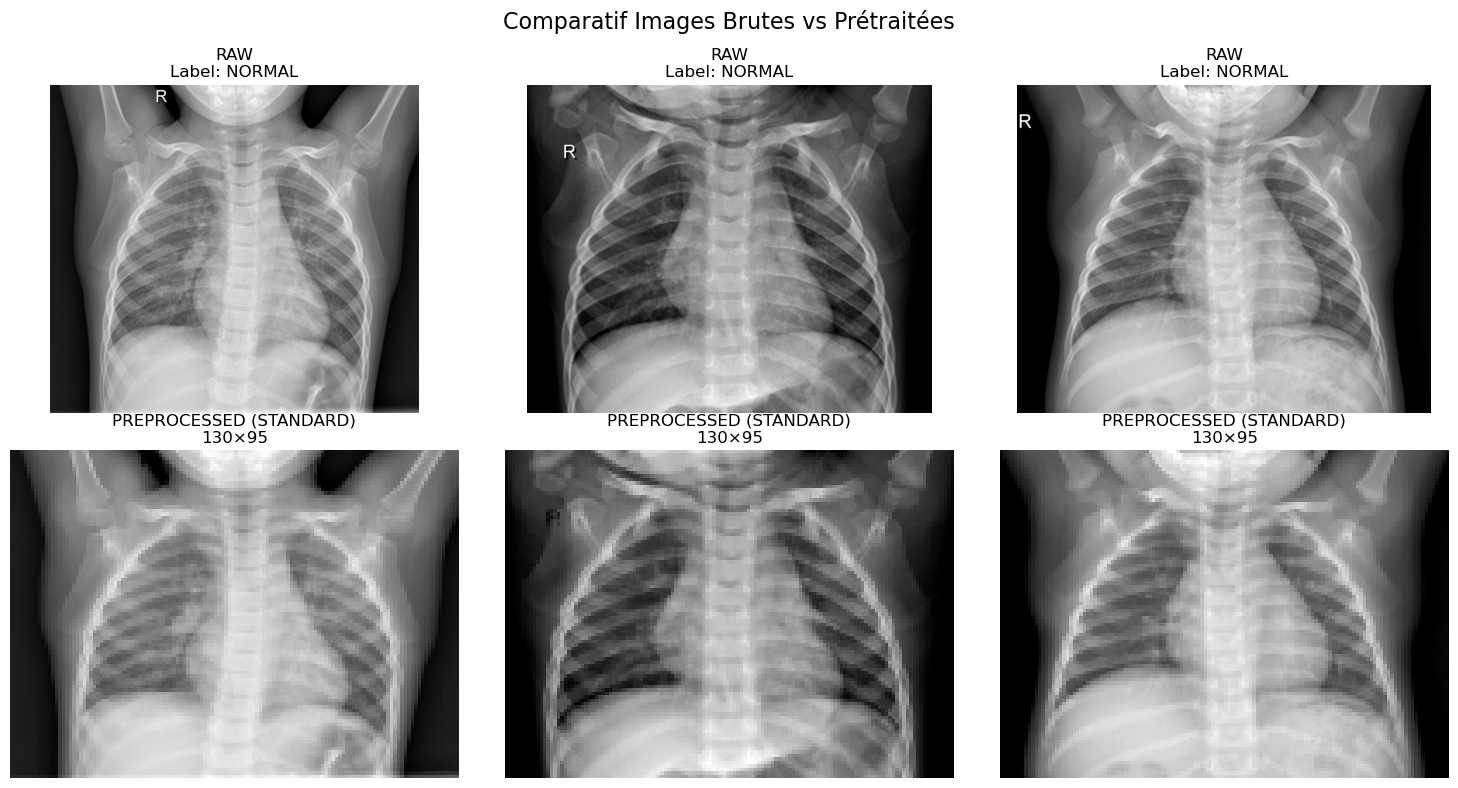

In [ ]:
show_raw_and_processed(df[df["split"] == "train"], n=3, apply_clahe=False)

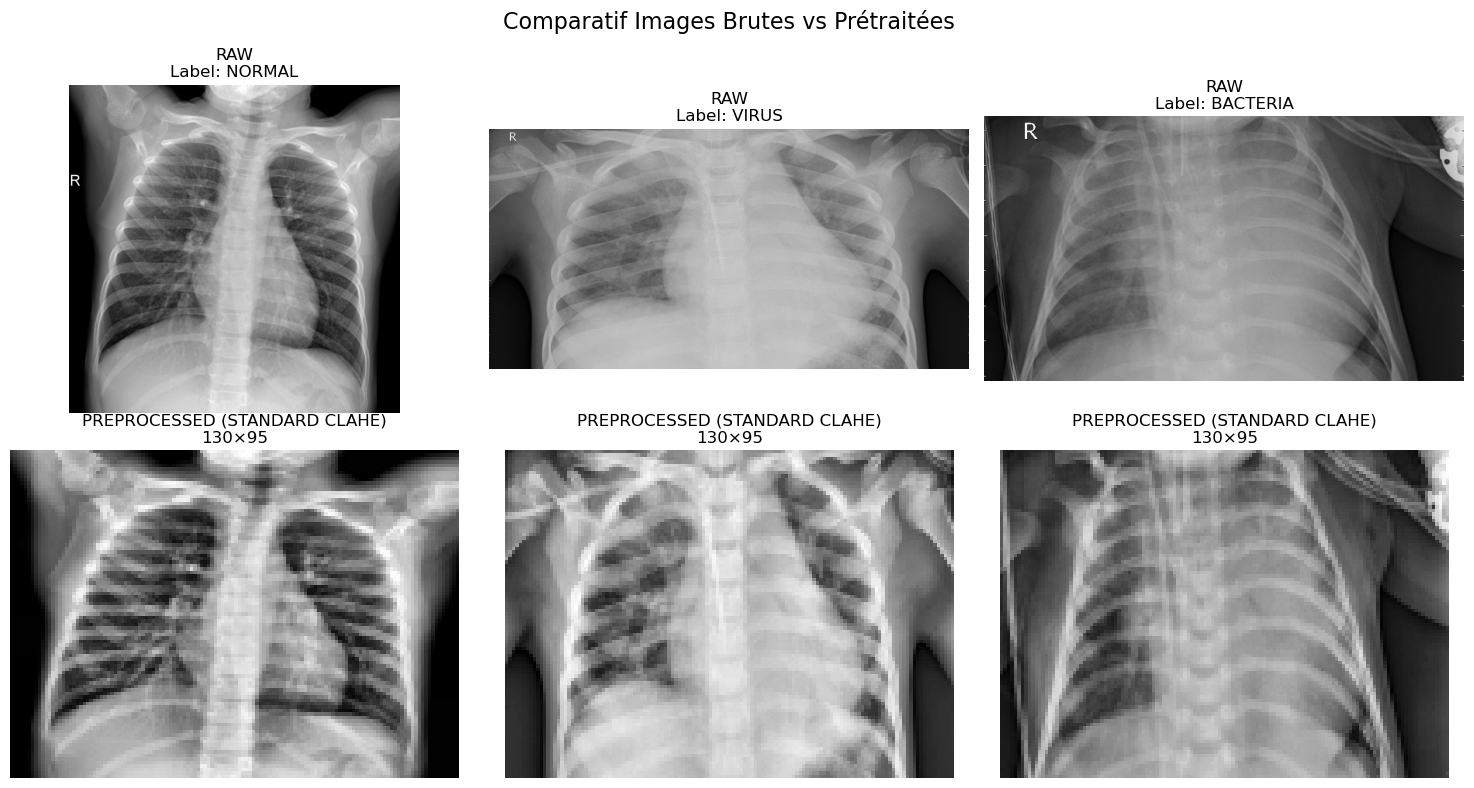

In [ ]:
show_raw_and_processed((df[df["split"] == "train"]).sample(n=3), n=3, size=(130, 95), apply_clahe=True)

# Train-test-split

## Fusion datasets de train + valid

In [ ]:
df_train = df[df["split"] == "train"]
df_val = df[df["split"] == "val"]

df_train_full = pd.concat([df_train, df_val], ignore_index=True)
df_train_full["split"] = "train"

In [ ]:
len(df_train_full)

4775

## Train-test-split stratifié 80/20

In [ ]:
# création du dataset de validation
from sklearn.model_selection import train_test_split

df_train, df_valid = train_test_split(
    df_train_full,
    test_size=0.2,
    stratify=df_train_full["label"],
    random_state=42
)

In [ ]:
df_test = df[df["split"] == "test"]

print("Nb images dans le jeu de train :", len(df_train))
print("Nb images dans le jeu de valid:", len(df_valid))
print("Nb images dans le jeu de test :", len(df_test))

Nb images dans le jeu de train : 3820
Nb images dans le jeu de valid: 955
Nb images dans le jeu de test : 304


# Récupération des X (images) et y (étiquettes) pour chaque jeu

In [ ]:
def build_dataset(df_subset, size=(130, 95), apply_clahe=False):
    label_mapping = {"NORMAL": 0, "BACTERIA": 1, "VIRUS": 2}
    y = (
        df_subset["label"]
        .map(label_mapping)
        .fillna(-1)
        .to_numpy(dtype=np.int64)
    )

    # Liste de matrices 2D, avec le prétraitement CLAHE activé
    X_list = [
        preprocess_image(p, size, apply_clahe=apply_clahe) for p in df_subset["path"]
    ]
    return np.array(X_list), y

In [ ]:
X_test, y_test = build_dataset(df_test, apply_clahe=True)
X_train, y_train = build_dataset(df_train, apply_clahe=True)
X_valid, y_valid = build_dataset(df_valid, apply_clahe=True)

In [ ]:
print(X_train[0:1], y_train[0:1])

[[[0.21176471 0.2        0.21568627 ... 0.20392157 0.15294118 0.10588235]
  [0.17254902 0.16862745 0.2        ... 0.16470588 0.11764706 0.06666667]
  [0.16470588 0.15294118 0.2        ... 0.14117647 0.08235294 0.02745098]
  ...
  [0.01176471 0.01176471 0.01176471 ... 0.01176471 0.01176471 0.01176471]
  [0.01176471 0.01176471 0.01176471 ... 0.01176471 0.01176471 0.01176471]
  [0.01176471 0.01176471 0.01176471 ... 0.01176471 0.01176471 0.01176471]]] [0]


In [ ]:
print(X_train.shape, y_train.shape)

(3820, 95, 130) (3820,)


In [ ]:
print(type(X_train))

<class 'numpy.ndarray'>


# Distribution des classes dans chaque jeu

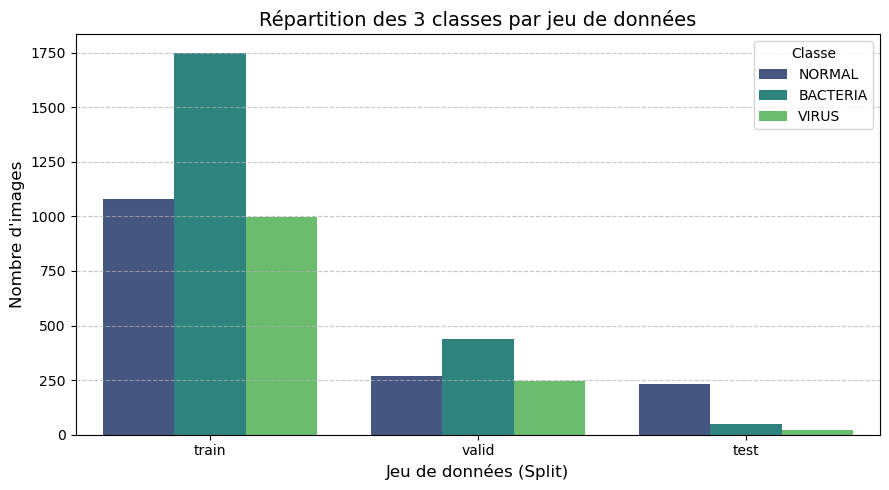

In [ ]:
import seaborn as sns

classes = ["NORMAL", "BACTERIA", "VIRUS"]

# np.bincount compte les occurrences de 0, 1 et 2 d'un seul coup
df_counts = pd.DataFrame({
    "NORMAL":   [np.bincount(y_train)[0], np.bincount(y_valid)[0], np.bincount(y_test)[0]],
    "BACTERIA": [np.bincount(y_train)[1], np.bincount(y_valid)[1], np.bincount(y_test)[1]],
    "VIRUS":    [np.bincount(y_train)[2], np.bincount(y_valid)[2], np.bincount(y_test)[2]],
    "split":    ["train", "valid", "test"]
})

# 2. On reformate le DataFrame pour Seaborn (format "Long")
df_melted = df_counts.melt(id_vars="split", var_name="label", value_name="count")

# 3. Plot avec Seaborn
plt.figure(figsize=(9, 5))
sns.barplot(
    data=df_melted,
    x="split",
    y="count",
    hue="label",
    hue_order=classes,
    palette="viridis"
)

plt.title("Répartition des 3 classes par jeu de données", fontsize=14)
plt.xlabel("Jeu de données (Split)", fontsize=12)
plt.ylabel("Nombre d'images", fontsize=12)
plt.legend(title="Classe")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# CLASSIFICATION CLASSES 'NORMAL' VS 'BACTERIA' VS 'VIRUS'

## Recherche hyperparamètres Balanced Random Forest Classifier

In [ ]:
from sklearn.model_selection import PredefinedSplit, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import recall_score, precision_score, roc_auc_score
from imblearn.ensemble import BalancedRandomForestClassifier

In [ ]:
# Aplanissement en vecteur 1D pour le Random Forest des 3 jeux
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_valid_flat = X_valid.reshape(X_valid.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

In [ ]:
print(X_train_flat.shape, y_train.shape)

(3820, 12350) (3820,)


In [ ]:
param_grid = {
    'n_estimators': [30, 50, 100, 300, 500],
    'max_depth': [3, 5, 10, 20, 30],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

In [ ]:
rf = BalancedRandomForestClassifier(random_state=42)

In [ ]:
# 5. Configurer la recherche pour optimiser le ROC AUC Multiclasse
grid_search = RandomizedSearchCV(
    estimator=rf, 
    param_distributions=param_grid,
    n_iter=50, 
    cv=5,              
    scoring='roc_auc_ovr',        # RECHERCHE BASEE SUR ROC AUC : recherche des hyperparamètres qui permettent au modèle de discriminer au mieux les 3 classes
    n_jobs = -1,
    verbose=0, 
    random_state=42
)

# Lancement de la recherche
grid_search.fit(X_train_flat, y_train)

print(f"Meilleurs hyperparamètres : {grid_search.best_params_}")
print(f"Meilleur ROC AUC score en cross-validation : {grid_search.best_score_:.4f}")


Meilleurs hyperparamètres : {'n_estimators': 500, 'min_samples_split': 5, 'max_features': 'sqrt', 'max_depth': 20}
Meilleur ROC AUC en cross-validation : 0.8967


In [ ]:
rfc = grid_search.best_estimator_
rfc

,n_estimators,500
,criterion,'gini'
,max_depth,20
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [ ]:
# utilisation du train augmenté pour le fit final avec les meilleurs hyperparamètres trouvés
rfc.fit(X_train_flat, y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,20
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


## Features les + importantes pour le modèle

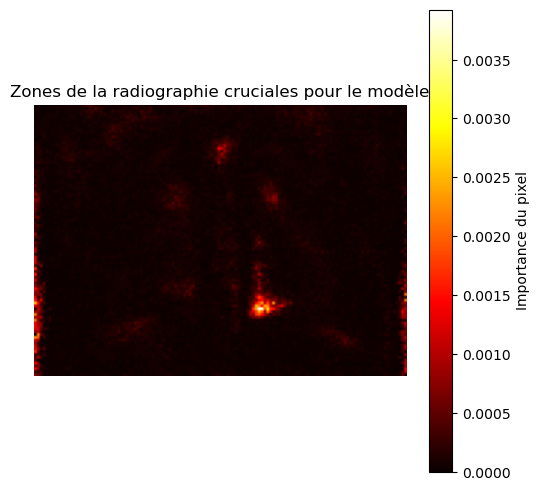

In [ ]:
import seaborn as sns

# 1. Récupérer les scores d'importance depuis ton modèle entraîné
importances = rfc.feature_importances_

taille_image = (95, 130) 

# Re-transformer le vecteur en une matrice 2D
heatmap_importance = importances.reshape(taille_image)

plt.figure(figsize=(6, 6))
plt.imshow(heatmap_importance, cmap='hot')
plt.colorbar(label='Importance du pixel')
plt.title("Zones de la radiographie cruciales pour le modèle")
plt.axis('off')
plt.show()


# Performances jeu de train

In [ ]:
class_names = ["NORMAL", "BACTERIA", "VIRUS"]

In [ ]:
y_pred_train = rfc.predict(X_train_flat)

In [ ]:
y_pred_proba_train = rfc.predict_proba(X_train_flat)

In [ ]:
# ROC-AUC
roc_auc = roc_auc_score(
    y_train, 
    y_pred_proba_train,
    multi_class="ovr")

print(f"ROC-AUC (train) : {roc_auc:.3f}")

ROC-AUC (train) : 1.000


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
        y_train,
        y_pred_train,
        target_names=[
            "NORMAL",
            "BACTERIA",
            "VIRUS"
        ]
    ))

              precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00      1079
    BACTERIA       1.00      0.99      0.99      1746
       VIRUS       0.98      1.00      0.99       995

    accuracy                           0.99      3820
   macro avg       0.99      1.00      0.99      3820
weighted avg       0.99      0.99      0.99      3820



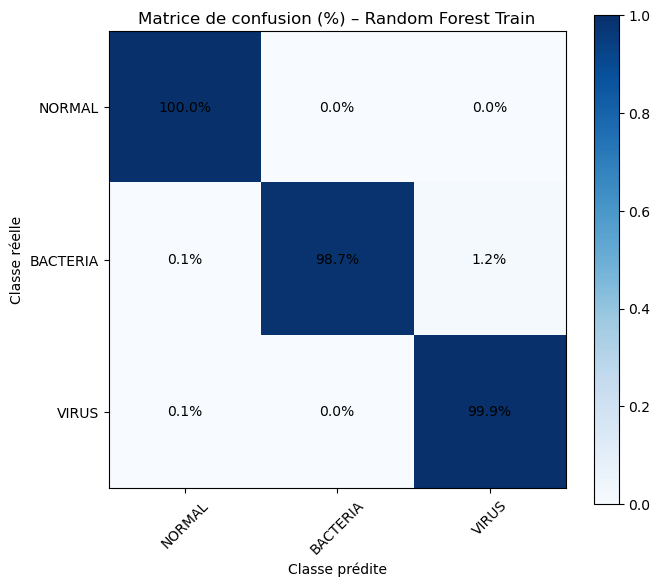

In [ ]:
from sklearn.metrics import confusion_matrix

# Matrice de confusion
cm_train = confusion_matrix(y_train, y_pred_train)

# Normalisation par ligne (classe réelle)
cm_normalized = cm_train.astype(float) / cm_train.sum(axis=1, keepdims=True)

plt.figure(figsize=(7, 6))
plt.imshow(cm_normalized, cmap="Blues")
plt.colorbar()

plt.xticks(
    np.arange(len(class_names)),
    class_names,
    rotation=45
)

plt.yticks(
    np.arange(len(class_names)),
    class_names
)

# Affichage des pourcentages dans chaque case
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            f"{cm_normalized[i, j]*100:.1f}%",
            ha="center",
            va="center",
            color="black"
        )

plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.title("Matrice de confusion (%) – Random Forest Train")

plt.tight_layout()
plt.show()

In [ ]:
# Sur le jeu de train
for i, true_class in enumerate(class_names):
    for j, pred_class in enumerate(class_names):
        print(
            f"Réel={true_class}, Prédit={pred_class} : {cm_train[i,j]}"
        )

Réel=NORMAL, Prédit=NORMAL : 1079
Réel=NORMAL, Prédit=BACTERIA : 0
Réel=NORMAL, Prédit=VIRUS : 0
Réel=BACTERIA, Prédit=NORMAL : 2
Réel=BACTERIA, Prédit=BACTERIA : 1723
Réel=BACTERIA, Prédit=VIRUS : 21
Réel=VIRUS, Prédit=NORMAL : 1
Réel=VIRUS, Prédit=BACTERIA : 0
Réel=VIRUS, Prédit=VIRUS : 994


In [ ]:
for classe, nom in enumerate(class_names):

    TP = cm_train[classe, classe]

    FN = cm_train[classe, :].sum() - TP

    FP = cm_train[:, classe].sum() - TP

    TN = cm_train.sum() - TP - FN - FP

    print(f"\n--- {nom} vs reste ---")
    print(f"TP : {TP}")
    print(f"FP : {FP}")
    print(f"FN : {FN}")
    print(f"TN : {TN}")


--- NORMAL vs reste ---
TP : 1079
FP : 3
FN : 0
TN : 2738

--- BACTERIA vs reste ---
TP : 1723
FP : 0
FN : 23
TN : 2074

--- VIRUS vs reste ---
TP : 994
FP : 21
FN : 1
TN : 2804


# Performances jeu de validation

In [ ]:
y_pred_valid = rfc.predict(X_valid_flat)
y_pred_proba_valid = rfc.predict_proba(X_valid_flat)

In [ ]:
roc_auc = roc_auc_score(
    y_valid, 
    y_pred_proba_valid,
    multi_class="ovr") # capacité globale du modèle à séparer les 3 classes, indépendamment du seuil

print(f"ROC-AUC (valid) : {roc_auc:.3f}")

ROC-AUC (valid) : 0.898


In [ ]:
print(classification_report(
        y_valid,
        y_pred_valid,
        target_names=[
            "NORMAL",
            "BACTERIA",
            "VIRUS"
        ]
    ))


              precision    recall  f1-score   support

      NORMAL       0.86      0.94      0.90       270
    BACTERIA       0.78      0.78      0.78       437
       VIRUS       0.61      0.56      0.58       248

    accuracy                           0.77       955
   macro avg       0.75      0.76      0.75       955
weighted avg       0.76      0.77      0.76       955



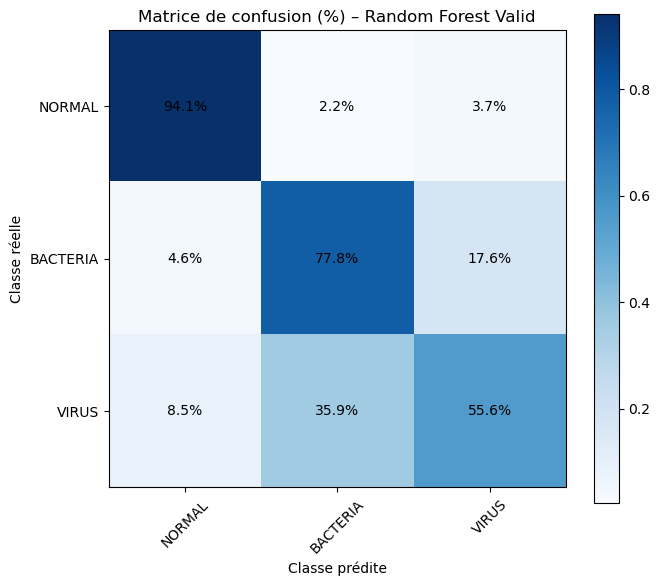

In [ ]:
# Matrice de confusion
cm_valid = confusion_matrix(y_valid, y_pred_valid)

# Normalisation par ligne (classe réelle)
cm_normalized = cm_valid.astype(float) / cm_valid.sum(axis=1, keepdims=True)

plt.figure(figsize=(7, 6))
plt.imshow(cm_normalized, cmap="Blues")
plt.colorbar()

plt.xticks(
    np.arange(len(class_names)),
    class_names,
    rotation=45
)

plt.yticks(
    np.arange(len(class_names)),
    class_names
)

# Affichage des pourcentages dans chaque case
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            f"{cm_normalized[i, j]*100:.1f}%",
            ha="center",
            va="center",
            color="black"
        )

plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.title("Matrice de confusion (%) – Random Forest Valid")

plt.tight_layout()
plt.show()

In [ ]:
for i, true_class in enumerate(class_names):
    for j, pred_class in enumerate(class_names):
        print(
            f"Réel={true_class}, Prédit={pred_class} : {cm_valid[i,j]}")

Réel=NORMAL, Prédit=NORMAL : 254
Réel=NORMAL, Prédit=BACTERIA : 6
Réel=NORMAL, Prédit=VIRUS : 10
Réel=BACTERIA, Prédit=NORMAL : 20
Réel=BACTERIA, Prédit=BACTERIA : 340
Réel=BACTERIA, Prédit=VIRUS : 77
Réel=VIRUS, Prédit=NORMAL : 21
Réel=VIRUS, Prédit=BACTERIA : 89
Réel=VIRUS, Prédit=VIRUS : 138


In [ ]:
for classe, nom in enumerate(class_names):

    TP = cm_valid[classe, classe]

    FN = cm_valid[classe, :].sum() - TP

    FP = cm_valid[:, classe].sum() - TP

    TN = cm_valid.sum() - TP - FN - FP

    print(f"\n--- {nom} vs reste ---")
    print(f"TP : {TP}")
    print(f"FP : {FP}")
    print(f"FN : {FN}")
    print(f"TN : {TN}")


--- NORMAL vs reste ---
TP : 254
FP : 41
FN : 16
TN : 644

--- BACTERIA vs reste ---
TP : 340
FP : 95
FN : 97
TN : 423

--- VIRUS vs reste ---
TP : 138
FP : 87
FN : 110
TN : 620


# Essai avec un seuil de décision pour classification : sur le jeu de validation

## Seuils pour maximiser la détection des NORMAL vs PNEUMONIE, puis BACTERIA vs VIRUS

### Scénario 1 : limiter au maximum les FN pour la catégorie NORMAL

In [ ]:
proba_valid_normal = y_pred_proba_valid[:, 0] # Probabilité d'être NORMAL selon le modèle
proba_valid_bacteria = y_pred_proba_valid[:, 1] # Probabilité d'être BACTERIE selon le modèle
proba_valid_virus = y_pred_proba_valid[:, 2] # Probabilité d'être VIRUS selon le modèle

# 1. On isole la probabilité globale d'être MALADE (Bacteria ou Virus)
# C'est l'inverse de la probabilité d'être sain (Normal)
proba_valid_malade = 1 - proba_valid_normal

In [ ]:
thresholds = np.linspace(0.05, 0.95, 300)
rows = []
#la classe d'intérêt (1 / True / Positive) correspond aux PNEUMONIES.
# Donc tout ce qui n'est pas NORMAL (différent de 0) devient True.
y_valid_malade = (y_valid != 0)

for t in thresholds:
    y_pred = (proba_valid_malade >= t).astype(int)
    TN, FP, FN, TP = confusion_matrix(y_valid_malade, y_pred).ravel()

    rows.append({
        "threshold": t,
        "FN": FN,
        "FP": FP,
        "recall": TP / (TP + FN),
        "fpr": FP / (FP + TN) # faux positifs / total des vrais négatifs
    })

df_thresh = pd.DataFrame(rows)

In [ ]:
df_thresh.head()

,threshold,FN,FP,recall,fpr
0,0.05000,0,262,1.0,0.970370
1,0.05301,0,261,1.0,0.966667
2,0.05602,0,260,1.0,0.962963
3,0.05903,0,258,1.0,0.955556
4,0.06204,0,257,1.0,0.951852


In [ ]:
print(df_thresh["recall"].min())
print(df_thresh["recall"].max())
print(df_thresh["fpr"].min())
print(df_thresh["fpr"].max())

0.4554744525547445
1.0
0.003703703703703704
0.9703703703703703


In [ ]:
df_sc1 = df_thresh[
    (df_thresh["recall"] >= 0.98)
]

In [ ]:
best_row_sc1 = (
    df_sc1
    .query(f"fpr <= {df_sc1['fpr'].min()}")
    .sort_values("FN")        
    .iloc[0]
)

print(best_row_sc1)

threshold     0.447324
FN           13.000000
FP           47.000000
recall        0.981022
fpr           0.174074
Name: 132, dtype: float64


In [ ]:
best_threshold_sc1 = best_row_sc1["threshold"]

best_threshold_sc1

np.float64(0.44732441471571904)

### Scénario 2 : Limiter les FN sans trop pénaliser les FP : indice de Younden

In [ ]:
#TROUVER LES MEILLEURS SEUILS POUR CHAQUE CLASSE
from sklearn.metrics import roc_curve

best_thresholds = {}

class_indices = [0, 1, 2]

# 2. Boucler sur chaque classe pour trouver son seuil optimal
for i, class_name in zip(class_indices, class_names):
    # Créer un y_valid binaire pour la classe en cours (1 si c'est la classe, 0 sinon)
    y_valid_binary = (y_valid == i).astype(int)
    
    # Récupérer les probabilités pour cette classe spécifique
    scores_for_class = y_pred_proba_valid[:, i]
    
    # Calculer la courbe ROC
    fpr, tpr, thresholds = roc_curve(y_valid_binary, scores_for_class)
    
    # Calculer l'indice de Youden pour chaque seuil
    youden_index = tpr - fpr

    # PIÈGE : On ignore le tout premier seuil (index 0) s'il vaut l'infini
    if thresholds[0] == np.inf or np.isinf(thresholds[0]):
        # On force l'indice de Youden du seuil infini à -1 pour l'éliminer
        youden_index[0] = -1
    
    # Trouver l'index du score maximum
    idx_optimal = np.argmax(youden_index)
    
    # Stocker le meilleur seuil
    best_thresholds[class_name] = thresholds[idx_optimal]

print("Seuils optimaux par classe :", best_thresholds)

Seuils optimaux par classe : {'NORMAL': np.float64(0.4083064788859304), 'BACTERIA': np.float64(0.3008281389749773), 'VIRUS': np.float64(0.36167969187214527)}


In [ ]:
best_threshold_sc2 = best_thresholds['NORMAL']

best_threshold_sc2

np.float64(0.4083064788859304)

In [ ]:
stop /|\%

## Performances jeu de test sans seuil

In [ ]:
y_pred= rfc.predict(X_test_flat)
y_pred_proba_test = rfc.predict_proba(X_test_flat)

In [ ]:
print(y_pred_proba_test)

[[0.51966667 0.22724274 0.25309059]
 [0.53966667 0.19234612 0.26798721]
 [0.52988239 0.21468638 0.25543124]
 [0.18887725 0.42837505 0.3827477 ]
 [0.31952468 0.29941576 0.38105956]
 [0.36051476 0.28075106 0.35873418]
 [0.58501618 0.18066688 0.23431695]
 [0.39522934 0.29968599 0.30508467]
 [0.24920484 0.42329064 0.32750452]
 [0.37972498 0.34149261 0.27878241]
 [0.567      0.18659018 0.24640982]
 [0.32788711 0.38142996 0.29068293]
 [0.57632522 0.19789035 0.22578443]
 [0.56915228 0.17028402 0.2605637 ]
 [0.49091384 0.25093013 0.25815603]
 [0.43633795 0.24146141 0.32220064]
 [0.16088557 0.51744644 0.321668  ]
 [0.56300641 0.21476465 0.22222894]
 [0.59499902 0.20828855 0.19671242]
 [0.48582956 0.21680649 0.29736396]
 [0.46601235 0.26746571 0.26652194]
 [0.48226497 0.24046195 0.27727308]
 [0.39330531 0.30684122 0.29985347]
 [0.60214266 0.20124123 0.19661612]
 [0.35367877 0.26311603 0.3832052 ]
 [0.46323901 0.22497547 0.31178552]
 [0.42497938 0.26196752 0.31305309]
 [0.41666429 0.33498034 0.24

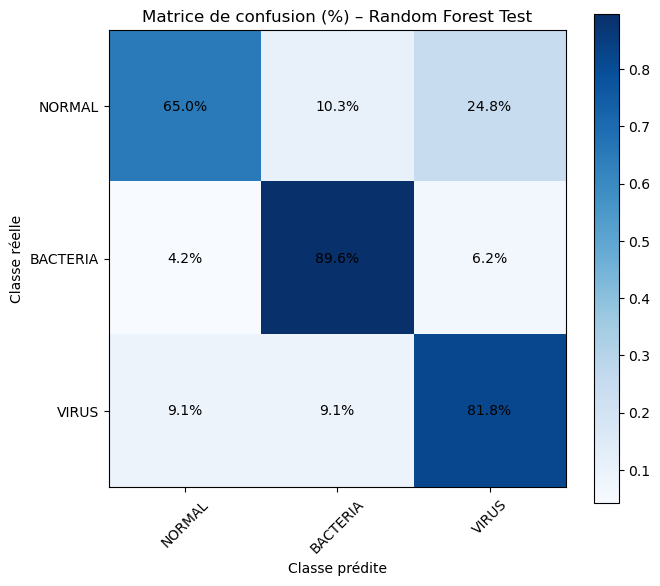

In [ ]:
# Matrice de confusion
cm_test = confusion_matrix(y_test, y_pred)

# Normalisation par ligne (classe réelle)
cm_normalized = cm_test.astype(float) / cm_test.sum(axis=1, keepdims=True)

# Noms des classes
class_names = ["NORMAL", "BACTERIA", "VIRUS"]

plt.figure(figsize=(7, 6))
plt.imshow(cm_normalized, cmap="Blues")
plt.colorbar()

plt.xticks(
    np.arange(len(class_names)),
    class_names,
    rotation=45
)

plt.yticks(
    np.arange(len(class_names)),
    class_names
)

# Affichage des pourcentages dans chaque case
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            f"{cm_normalized[i, j]*100:.1f}%",
            ha="center",
            va="center",
            color="black"
        )

plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.title("Matrice de confusion (%) – Random Forest Test")

plt.tight_layout()
plt.show()

In [ ]:
roc_auc = roc_auc_score(
    y_test, 
    y_pred_proba_test,
    multi_class="ovr") # capacité globale du modèle à séparer les 3 classes, indépendamment du seuil

print(f"ROC-AUC (test) : {roc_auc:.3f}")

ROC-AUC (test) : 0.927


In [ ]:
print(classification_report(
        y_test,
        y_pred,
        target_names=[
            "NORMAL",
            "BACTERIA",
            "VIRUS"
        ]
    ))


              precision    recall  f1-score   support

      NORMAL       0.97      0.65      0.78       234
    BACTERIA       0.62      0.90      0.74        48
       VIRUS       0.23      0.82      0.36        22

    accuracy                           0.70       304
   macro avg       0.61      0.79      0.62       304
weighted avg       0.86      0.70      0.74       304



In [ ]:
class_names = ["NORMAL", "BACTERIA", "VIRUS"]

for i, true_class in enumerate(class_names):
    for j, pred_class in enumerate(class_names):
        print(
            f"Réel={true_class}, Prédit={pred_class} : {cm_test[i,j]}")

Réel=NORMAL, Prédit=NORMAL : 152
Réel=NORMAL, Prédit=BACTERIA : 24
Réel=NORMAL, Prédit=VIRUS : 58
Réel=BACTERIA, Prédit=NORMAL : 2
Réel=BACTERIA, Prédit=BACTERIA : 43
Réel=BACTERIA, Prédit=VIRUS : 3
Réel=VIRUS, Prédit=NORMAL : 2
Réel=VIRUS, Prédit=BACTERIA : 2
Réel=VIRUS, Prédit=VIRUS : 18


## Performances jeu de test avec seuil

In [ ]:
# classement "en cascade" des prédictions en fonction des seuils des 2 scénarios
# d'abord on applique le seuil optimisé pour la distinction NORMAL/MALADE, 
# puis on reclassifie BACTERIA et VIRUS avec les seuils optimaux respectifs

def predict_cascade(y_prob_matrix, thresh_malade, thresh_bacteria, thresh_virus):
    """
    y_prob_matrix : probabilités de predict_proba() [NORMAL, BACTERIA, VIRUS]
    thresh_malade : seuil de détection de la maladie (Scénario 1 ou Youden)
    thresh_bacteria : seuil Youden pour BACTERIA
    thresh_virus : seuil Youden pour VIRUS
    """
    final_predictions = []
    
    for probs in y_prob_matrix:
        # 1. On calcule le risque d'être malade
        prob_malade = 1 - probs[0] 
        
        # ÉTAPE 1 : Si le risque de maladie dépasse notre seuil de sécurité
        if prob_malade >= thresh_malade:
            
            # ÉTAPE 2 : Le patient est malade. On utilise les seuils Youden pour Bacteria vs Virus
            score_bacteria = probs[1] / (thresh_bacteria if thresh_bacteria > 0 else 1e-6)
            score_virus = probs[2] / (thresh_virus if thresh_virus > 0 else 1e-6)
            
            if score_bacteria > score_virus:
                final_predictions.append(1) # Prédit BACTERIA
            else:
                final_predictions.append(2) # Prédit VIRUS
        else:
            # Le risque est trop faible, le patient est sain
            final_predictions.append(0) # Prédit NORMAL
            
    return np.array(final_predictions)

### Scénario 1

In [ ]:
y_pred_sc1 = predict_cascade(
    y_pred_proba_test, 
    thresh_malade=best_threshold_sc1,
    thresh_bacteria=1,                 # On met 1 pour ne pas modifier le score brut
    thresh_virus=1)

In [ ]:
cm_sc1 = confusion_matrix(y_test, y_pred_sc1)

print(f"Seuil utilisé : {best_threshold_sc1}")

print(classification_report(
        y_test,
        y_pred_sc1,
        target_names=[
            "NORMAL",
            "BACTERIA",
            "VIRUS"
        ]
    ))

Seuil utilisé : 0.44732441471571904
              precision    recall  f1-score   support

      NORMAL       1.00      0.26      0.41       234
    BACTERIA       0.44      0.92      0.60        48
       VIRUS       0.13      0.86      0.23        22

    accuracy                           0.41       304
   macro avg       0.53      0.68      0.41       304
weighted avg       0.85      0.41      0.43       304



In [ ]:
class_names = ["NORMAL", "BACTERIA", "VIRUS"]

for i, true_class in enumerate(class_names):
    for j, pred_class in enumerate(class_names):
        print(
            f"Réel={true_class}, Prédit={pred_class} : {cm_sc1[i,j]}")

Réel=NORMAL, Prédit=NORMAL : 61
Réel=NORMAL, Prédit=BACTERIA : 52
Réel=NORMAL, Prédit=VIRUS : 121
Réel=BACTERIA, Prédit=NORMAL : 0
Réel=BACTERIA, Prédit=BACTERIA : 44
Réel=BACTERIA, Prédit=VIRUS : 4
Réel=VIRUS, Prédit=NORMAL : 0
Réel=VIRUS, Prédit=BACTERIA : 3
Réel=VIRUS, Prédit=VIRUS : 19


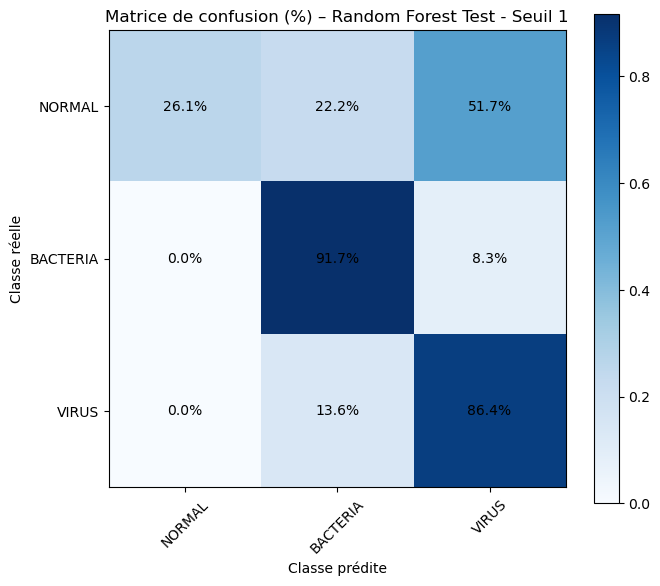

In [ ]:
# Normalisation par ligne (classe réelle)
cm_normalized = cm_sc1.astype(float) / cm_sc1.sum(axis=1, keepdims=True)

# Noms des classes
class_names = ["NORMAL", "BACTERIA", "VIRUS"]

plt.figure(figsize=(7, 6))
plt.imshow(cm_normalized, cmap="Blues")
plt.colorbar()

plt.xticks(
    np.arange(len(class_names)),
    class_names,
    rotation=45
)

plt.yticks(
    np.arange(len(class_names)),
    class_names
)

# Affichage des pourcentages dans chaque case
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            f"{cm_normalized[i, j]*100:.1f}%",
            ha="center",
            va="center",
            color="black"
        )

plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.title("Matrice de confusion (%) – Random Forest Test - Seuil 1")

plt.tight_layout()
plt.show()

### Scénario 2

In [ ]:
seuil_maladie_youden = 1 - best_thresholds['NORMAL']

y_pred_sc2 = predict_cascade(
    y_pred_proba_test, 
    thresh_malade=seuil_maladie_youden,       # Seuil Youden converti en risque maladie
    thresh_bacteria=best_thresholds['BACTERIA'], # Seuil Youden Bacteria
    thresh_virus=best_thresholds['VIRUS']        # Seuil Youden Virus
)

In [ ]:
cm_sc2 = confusion_matrix(y_test, y_pred_sc2)

print(f"Seuil utilisé : {best_threshold_sc2}")

print(classification_report(
        y_test,
        y_pred_sc2,
        target_names=[
            "NORMAL",
            "BACTERIA",
            "VIRUS"
        ]
    ))

Seuil utilisé : 0.4083064788859304
              precision    recall  f1-score   support

      NORMAL       0.98      0.56      0.71       234
    BACTERIA       0.45      0.94      0.60        48
       VIRUS       0.27      0.86      0.41        22

    accuracy                           0.64       304
   macro avg       0.57      0.79      0.57       304
weighted avg       0.85      0.64      0.67       304



In [ ]:
class_names = ["NORMAL", "BACTERIA", "VIRUS"]

for i, true_class in enumerate(class_names):
    for j, pred_class in enumerate(class_names):
        print(
            f"Réel={true_class}, Prédit={pred_class} : {cm_sc2[i,j]}")

Réel=NORMAL, Prédit=NORMAL : 130
Réel=NORMAL, Prédit=BACTERIA : 53
Réel=NORMAL, Prédit=VIRUS : 51
Réel=BACTERIA, Prédit=NORMAL : 2
Réel=BACTERIA, Prédit=BACTERIA : 45
Réel=BACTERIA, Prédit=VIRUS : 1
Réel=VIRUS, Prédit=NORMAL : 0
Réel=VIRUS, Prédit=BACTERIA : 3
Réel=VIRUS, Prédit=VIRUS : 19


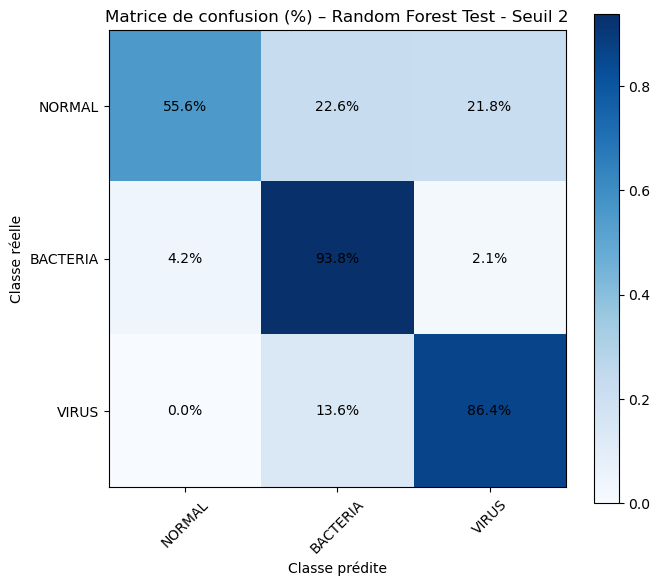

In [ ]:
# Normalisation par ligne (classe réelle)
cm_normalized = cm_sc2.astype(float) / cm_sc2.sum(axis=1, keepdims=True)

# Noms des classes
class_names = ["NORMAL", "BACTERIA", "VIRUS"]

plt.figure(figsize=(7, 6))
plt.imshow(cm_normalized, cmap="Blues")
plt.colorbar()

plt.xticks(
    np.arange(len(class_names)),
    class_names,
    rotation=45
)

plt.yticks(
    np.arange(len(class_names)),
    class_names
)

# Affichage des pourcentages dans chaque case
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            f"{cm_normalized[i, j]*100:.1f}%",
            ha="center",
            va="center",
            color="black"
        )

plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.title("Matrice de confusion (%) – Random Forest Test - Seuil 2")

plt.tight_layout()
plt.show()

# Quelles images sont encore des FN ?

In [ ]:
df_test = df[df["split"] == "test"].reset_index(drop=True)

fn_idx = np.where((y_test != 0) & (y_pred_sc2 == 0))[0]

In [ ]:
def show_errors(df_test, fn_indices, max_images=10):
    n = min(len(fn_indices), max_images)

    plt.figure(figsize=(15, 4 * ((n + 3) // 4)))

    for i, idx in enumerate(fn_indices[:n]):
        img_path = df_test.loc[idx, "path"]
        label = df_test.loc[idx, "label"]
        patient_id = df_test.loc[idx, "patient_id"]

        img = Image.open(img_path).convert("L")

        plt.subplot((n + 3) // 4, 4, i + 1)
        plt.imshow(img, cmap="gray")
        plt.axis("off")
        plt.title(f"FN – {label}\nPatient ID: {patient_id}")

    plt.suptitle("Faux négatifs (cas de PNEUMONIA prédit NORMAL)", fontsize=16)
    plt.tight_layout()
    plt.show()


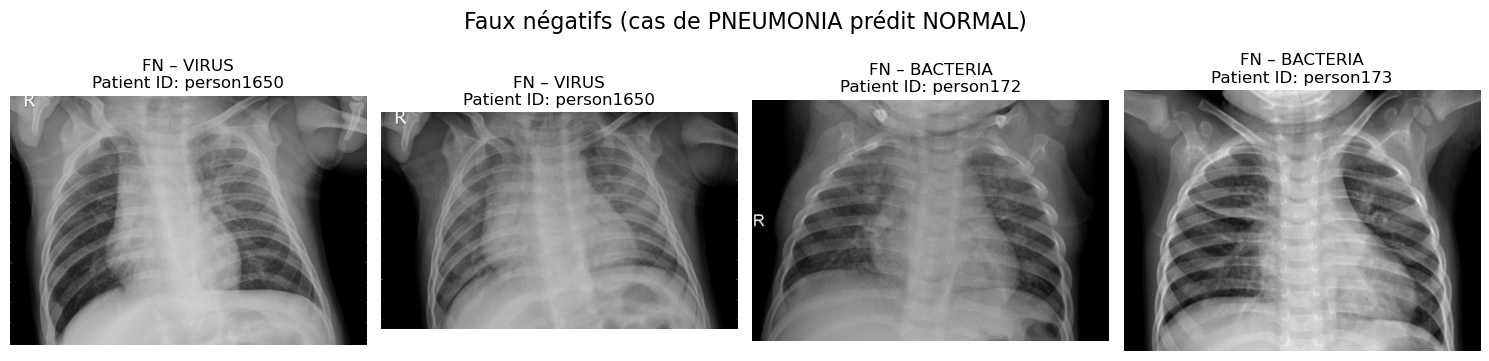

In [ ]:
show_errors(df_test, fn_idx, max_images=10)
